## 1. Imports and Setup

In [22]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet50
import cv2
import numpy as np
from PIL import Image
import time
import os

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 2. Model Architecture

In [23]:
def create_stage1_model():
    """Create Stage 1 model (Normal vs Cataract) - matching saved model architecture"""
    model = resnet50(weights=None)
    num_features = model.fc.in_features
    # Stage 1 architecture: Linear(2048, 256) -> ReLU -> Dropout -> Linear(256, 1)
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )
    return model


def create_stage2_model():
    """Create Stage 2 model (Mature vs Immature) - matching saved model architecture"""
    model = resnet50(weights=None)
    num_features = model.fc.in_features
    # Stage 2 architecture: More complex with BatchNorm layers, single output
    # fc.1, fc.2 (BN), fc.5, fc.6 (BN), fc.9
    model.fc = nn.Sequential(
        nn.Flatten(),                         # 0
        nn.Linear(num_features, 512),         # 1
        nn.BatchNorm1d(512),                  # 2
        nn.ReLU(),                            # 3
        nn.Dropout(0.3),                      # 4
        nn.Linear(512, 256),                  # 5
        nn.BatchNorm1d(256),                  # 6
        nn.ReLU(),                            # 7
        nn.Dropout(0.3),                      # 8
        nn.Linear(256, 1)                     # 9 - single output for binary classification
    )
    return model


print("Model architectures defined (matching saved model formats).")

Model architectures defined (matching saved model formats).


## 3. Load Trained Models

In [24]:
# Paths to trained models
STAGE1_MODEL_PATH = 'stage1_cataract_normal_model.pth'
STAGE2_MODEL_PATH = 'stage2_mature_immature_model.pth'

# Check if models exist
if not os.path.exists(STAGE1_MODEL_PATH):
    print(f"WARNING: {STAGE1_MODEL_PATH} not found!")
    print("Please train Stage 1 model first using Cascading_Cataract_Classification_Final.ipynb")
else:
    print(f"✓ Stage 1 model found: {STAGE1_MODEL_PATH}")

if not os.path.exists(STAGE2_MODEL_PATH):
    print(f"WARNING: {STAGE2_MODEL_PATH} not found!")
    print("Please train Stage 2 model first using Cascading_Cataract_Classification_Final.ipynb")
else:
    print(f"✓ Stage 2 model found: {STAGE2_MODEL_PATH}")

✓ Stage 1 model found: stage1_cataract_normal_model.pth
✓ Stage 2 model found: stage2_mature_immature_model.pth


In [25]:
# Load Stage 1 Model (Normal vs Cataract)
stage1_model = create_stage1_model()
stage1_model.load_state_dict(torch.load(STAGE1_MODEL_PATH, map_location=device, weights_only=True))
stage1_model.to(device)
stage1_model.eval()
print("Stage 1 model loaded successfully!")

# Load Stage 2 Model (Mature vs Immature)
stage2_model = create_stage2_model()
stage2_model.load_state_dict(torch.load(STAGE2_MODEL_PATH, map_location=device, weights_only=True))
stage2_model.to(device)
stage2_model.eval()
print("Stage 2 model loaded successfully!")

Stage 1 model loaded successfully!
Stage 2 model loaded successfully!
Stage 2 model loaded successfully!


## 4. Image Preprocessing

In [26]:
# Image transformation pipeline
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Class labels
STAGE1_CLASSES = ['Cataract', 'Normal']  # 0: Cataract, 1: Normal
STAGE2_CLASSES = ['Immature', 'Mature']  # 0: Immature, 1: Mature

print("Preprocessing pipeline ready.")
print(f"Stage 1 classes: {STAGE1_CLASSES}")
print(f"Stage 2 classes: {STAGE2_CLASSES}")

Preprocessing pipeline ready.
Stage 1 classes: ['Cataract', 'Normal']
Stage 2 classes: ['Immature', 'Mature']


## 5. Classification Functions

In [ ]:
def preprocess_frame(frame):
    """
    Preprocess a frame from OpenCV (BGR) to PyTorch tensor
    """
    # Convert BGR to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Convert to PIL Image
    pil_image = Image.fromarray(rgb_frame)
    # Apply transformations
    tensor = transform(pil_image)
    # Add batch dimension
    tensor = tensor.unsqueeze(0)
    return tensor.to(device)


# Minimum confidence threshold - if model is less confident than this, 
# it means the input doesn't look like an eye image
MIN_CONFIDENCE_THRESHOLD = 70.0  # Adjust this value as needed (60-80 recommended)


def classify_frame(frame, confidence_threshold=MIN_CONFIDENCE_THRESHOLD):
    """
    Perform cascading classification on a single frame
    Returns: (final_class, confidence, stage1_result, stage2_result)
    
    If the model's confidence is below the threshold, returns "No Eye Detected"
    to avoid false classifications on non-eye images (like empty webcam frames).
    
    Stage 1: Binary classification (single output with sigmoid)
        - output > 0.5 → Normal (class 1)
        - output <= 0.5 → Cataract (class 0)
    
    Stage 2: Binary classification (single output with sigmoid)
        - output > 0.5 → Mature (class 1)
        - output <= 0.5 → Immature (class 0)
    """
    # Preprocess
    tensor = preprocess_frame(frame)
    
    with torch.no_grad():
        # Stage 1: Normal vs Cataract (binary: sigmoid output)
        stage1_output = stage1_model(tensor)
        stage1_prob = torch.sigmoid(stage1_output).item()
        
        # Calculate confidence (how far from 0.5 the prediction is)
        # Confidence = distance from decision boundary (0.5) scaled to percentage
        stage1_conf = abs(stage1_prob - 0.5) * 200  # Maps 0.5-1.0 or 0.5-0.0 to 0-100%
        
        # If confidence is too low, the input probably isn't an eye image
        if stage1_conf < confidence_threshold:
            return 'No Eye Detected', stage1_conf, ('Uncertain', stage1_conf), None
        
        # Stage 1: prob > 0.5 = Normal, prob <= 0.5 = Cataract
        if stage1_prob > 0.5:
            stage1_class = 'Normal'
            stage1_conf_display = stage1_prob * 100
        else:
            stage1_class = 'Cataract'
            stage1_conf_display = (1 - stage1_prob) * 100
        
        # If Normal, return early
        if stage1_class == 'Normal':
            return 'Normal', stage1_conf_display, (stage1_class, stage1_conf_display), None
        
        # Stage 2: Mature vs Immature (binary: sigmoid output)
        stage2_output = stage2_model(tensor)
        stage2_prob = torch.sigmoid(stage2_output).item()
        
        # Stage 2: prob > 0.5 = Mature, prob <= 0.5 = Immature
        if stage2_prob > 0.5:
            stage2_class = 'Mature'
            stage2_conf = stage2_prob * 100
        else:
            stage2_class = 'Immature'
            stage2_conf = (1 - stage2_prob) * 100
        
        final_class = f"{stage2_class} Cataract"
        return final_class, stage2_conf, (stage1_class, stage1_conf_display), (stage2_class, stage2_conf)


print("Classification functions ready.")
print(f"Minimum confidence threshold: {MIN_CONFIDENCE_THRESHOLD}%")
print("Images with confidence below threshold will show 'No Eye Detected'")

Classification functions ready.


## 6. Display Functions

In [ ]:
def draw_classification_overlay(frame, final_class, confidence, stage1_result, stage2_result, fps):
    """
    Draw classification results on the frame
    """
    h, w = frame.shape[:2]
    
    # Colors based on classification
    if 'No Eye' in final_class:
        color = (128, 128, 128)  # Gray for No Eye Detected
        bg_color = (50, 50, 50)
    elif 'Normal' in final_class:
        color = (0, 255, 0)  # Green for Normal
        bg_color = (0, 100, 0)
    elif 'Immature' in final_class:
        color = (0, 255, 255)  # Yellow for Immature
        bg_color = (0, 100, 100)
    else:  # Mature
        color = (0, 0, 255)  # Red for Mature
        bg_color = (0, 0, 100)
    
    # Draw semi-transparent background for text
    overlay = frame.copy()
    cv2.rectangle(overlay, (10, 10), (400, 160), bg_color, -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
    
    # Draw border
    cv2.rectangle(frame, (10, 10), (400, 160), color, 2)
    
    # Title
    cv2.putText(frame, "Cataract Classification", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Final classification
    cv2.putText(frame, f"Result: {final_class}", (20, 75),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    
    if 'No Eye' in final_class:
        cv2.putText(frame, "Please show an eye image", (20, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        cv2.putText(frame, f"Model uncertainty: {100-confidence:.1f}%", (20, 125),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    else:
        cv2.putText(frame, f"Confidence: {confidence:.1f}%", (20, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        
        # Stage details
        stage1_text = f"Stage 1: {stage1_result[0]} ({stage1_result[1]:.1f}%)"
        cv2.putText(frame, stage1_text, (20, 125),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        if stage2_result:
            stage2_text = f"Stage 2: {stage2_result[0]} ({stage2_result[1]:.1f}%)"
            cv2.putText(frame, stage2_text, (20, 145),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        else:
            cv2.putText(frame, "Stage 2: N/A (Normal eye)", (20, 145),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    
    # FPS counter
    cv2.putText(frame, f"FPS: {fps:.1f}", (w - 100, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Instructions
    cv2.putText(frame, "Press 'q' to quit | 's' to save screenshot", (10, h - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    
    return frame


print("Display functions ready.")

Display functions ready.


## 7. Real-Time Classification (Webcam)

In [29]:
def run_realtime_classification(camera_index=0, window_width=800, window_height=600):
    """
    Run real-time cataract classification using webcam
    
    Args:
        camera_index: Camera device index (0 for default webcam)
        window_width: Display window width
        window_height: Display window height
    
    Controls:
        'q' - Quit
        's' - Save screenshot
        'p' - Pause/Resume
    """
    print("Starting real-time classification...")
    print("Press 'q' to quit, 's' to save screenshot, 'p' to pause/resume")
    
    # Open camera
    cap = cv2.VideoCapture(camera_index)
    
    if not cap.isOpened():
        print(f"Error: Could not open camera {camera_index}")
        return
    
    # Set camera resolution
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, window_width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, window_height)
    
    # FPS calculation variables
    fps = 0
    frame_count = 0
    start_time = time.time()
    
    # State
    paused = False
    screenshot_count = 0
    
    # Last classification result (for paused display)
    last_result = None
    
    try:
        while True:
            if not paused:
                ret, frame = cap.read()
                if not ret:
                    print("Error: Could not read frame")
                    break
                
                # Classify the frame
                final_class, confidence, stage1_result, stage2_result = classify_frame(frame)
                last_result = (frame.copy(), final_class, confidence, stage1_result, stage2_result)
                
                # Calculate FPS
                frame_count += 1
                elapsed_time = time.time() - start_time
                if elapsed_time > 1.0:
                    fps = frame_count / elapsed_time
                    frame_count = 0
                    start_time = time.time()
            
            # Use last result for display
            if last_result:
                display_frame, final_class, confidence, stage1_result, stage2_result = last_result
                display_frame = display_frame.copy()
                
                # Draw overlay
                display_frame = draw_classification_overlay(
                    display_frame, final_class, confidence, 
                    stage1_result, stage2_result, fps
                )
                
                # Show paused indicator
                if paused:
                    cv2.putText(display_frame, "PAUSED", (display_frame.shape[1]//2 - 60, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
                
                # Display
                cv2.imshow('Real-Time Cataract Classification', display_frame)
            
            # Handle key presses
            key = cv2.waitKey(1) & 0xFF
            
            if key == ord('q'):
                print("Quitting...")
                break
            elif key == ord('s'):
                # Save screenshot
                screenshot_name = f"cataract_screenshot_{screenshot_count}.png"
                cv2.imwrite(screenshot_name, display_frame)
                print(f"Screenshot saved: {screenshot_name}")
                screenshot_count += 1
            elif key == ord('p'):
                paused = not paused
                print("Paused" if paused else "Resumed")
                
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Camera released and windows closed.")

In [ ]:
# Run real-time webcam classification
# Press 'q' to quit, 's' to save screenshot, 'p' to pause/resume
run_realtime_classification(camera_index=0)

Starting real-time classification...
Press 'q' to quit, 's' to save screenshot, 'p' to pause/resume


## 8. Run Real-Time Classification

**Note:** Running this cell will open a camera window. Make sure your webcam is connected.

In [30]:
# Run real-time classification
# Change camera_index if you have multiple cameras (0, 1, 2, ...)
run_realtime_classification(camera_index=0)

Starting real-time classification...
Press 'q' to quit, 's' to save screenshot, 'p' to pause/resume
Error: Could not open camera 0
Error: Could not open camera 0


OpenCV: not authorized to capture video (status 0), requesting...
OpenCV: camera failed to properly initialize!


---

## Alternative: Classify Single Image

If you don't have a webcam or want to test with a single image:

In [31]:
def classify_single_image(image_path):
    """
    Classify a single image file
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found: {image_path}")
        return
    
    # Read image
    frame = cv2.imread(image_path)
    if frame is None:
        print(f"Error: Could not read image: {image_path}")
        return
    
    # Classify
    final_class, confidence, stage1_result, stage2_result = classify_frame(frame)
    
    # Draw overlay
    result_frame = draw_classification_overlay(
        frame.copy(), final_class, confidence,
        stage1_result, stage2_result, fps=0
    )
    
    # Display results
    print("\n" + "="*50)
    print(f"Image: {image_path}")
    print("="*50)
    print(f"\nFinal Classification: {final_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nStage 1 (Normal/Cataract): {stage1_result[0]} ({stage1_result[1]:.2f}%)")
    if stage2_result:
        print(f"Stage 2 (Mature/Immature): {stage2_result[0]} ({stage2_result[1]:.2f}%)")
    print("="*50)
    
    # Show image (if running in environment with display)
    cv2.imshow('Classification Result', result_frame)
    print("\nPress any key to close the image window...")
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    return final_class, confidence, stage1_result, stage2_result

In [32]:
# Example: Classify a single image
# Uncomment and modify the path to test with your image

# classify_single_image('path/to/your/eye_image.jpg')

# Or test with sample images from the dataset:
# classify_single_image('cataract_normal/test/cataract/image1.jpg')
# classify_single_image('cataract_normal/test/normal/image1.jpg')
# classify_single_image('mature_immature/test/Mature/image1.jpg')

---

## Alternative: Classify from Image File Path (No Display)

In [33]:
def classify_image_no_display(image_path):
    """
    Classify an image without opening display windows
    Useful for notebooks or headless environments
    """
    from PIL import Image as PILImage
    import matplotlib.pyplot as plt
    
    if not os.path.exists(image_path):
        print(f"Error: Image not found: {image_path}")
        return
    
    # Read image
    frame = cv2.imread(image_path)
    if frame is None:
        print(f"Error: Could not read image: {image_path}")
        return
    
    # Classify
    final_class, confidence, stage1_result, stage2_result = classify_frame(frame)
    
    # Display using matplotlib
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(rgb_frame)
    ax.axis('off')
    
    # Title with classification
    title = f"Classification: {final_class}\nConfidence: {confidence:.2f}%\n"
    title += f"Stage 1: {stage1_result[0]} ({stage1_result[1]:.2f}%)"
    if stage2_result:
        title += f"\nStage 2: {stage2_result[0]} ({stage2_result[1]:.2f}%)"
    
    # Color based on result
    if 'Normal' in final_class:
        color = 'green'
    elif 'Immature' in final_class:
        color = 'orange'
    else:
        color = 'red'
    
    ax.set_title(title, fontsize=14, color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return final_class, confidence, stage1_result, stage2_result

In [34]:
# Test with sample images from dataset
import glob

# Get sample images
cataract_images = glob.glob('cataract_normal/test/cataract/*')[:2]
normal_images = glob.glob('cataract_normal/test/normal/*')[:2]
mature_images = glob.glob('mature_immature/test/Mature/*')[:2]
immature_images = glob.glob('mature_immature/test/Immature/*')[:2]

print("Sample images found:")
print(f"  Cataract: {len(cataract_images)}")
print(f"  Normal: {len(normal_images)}")
print(f"  Mature: {len(mature_images)}")
print(f"  Immature: {len(immature_images)}")

Sample images found:
  Cataract: 2
  Normal: 2
  Mature: 2
  Immature: 2



Classifying a cataract image:


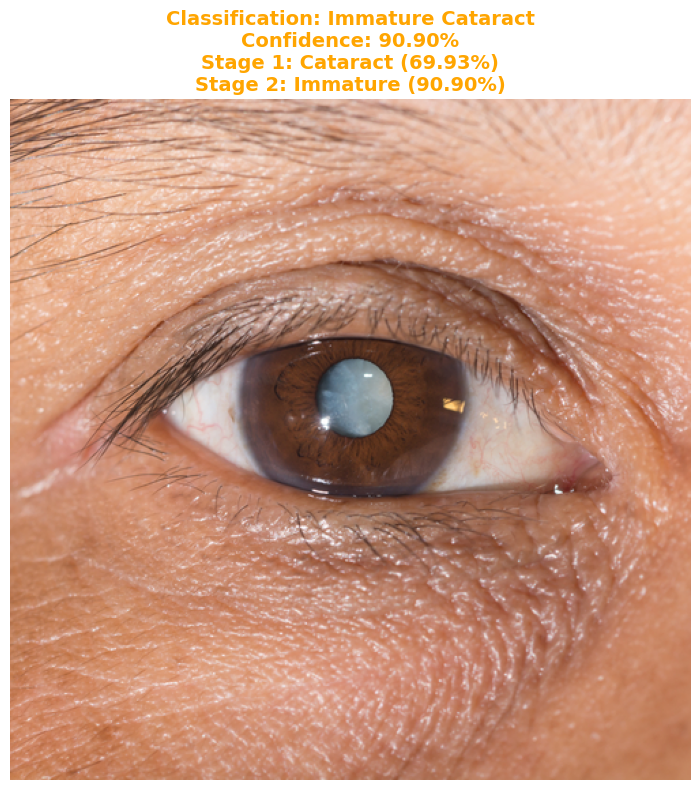

In [35]:
# Classify sample images
if cataract_images:
    print("\nClassifying a cataract image:")
    classify_image_no_display(cataract_images[0])


Classifying a normal image:


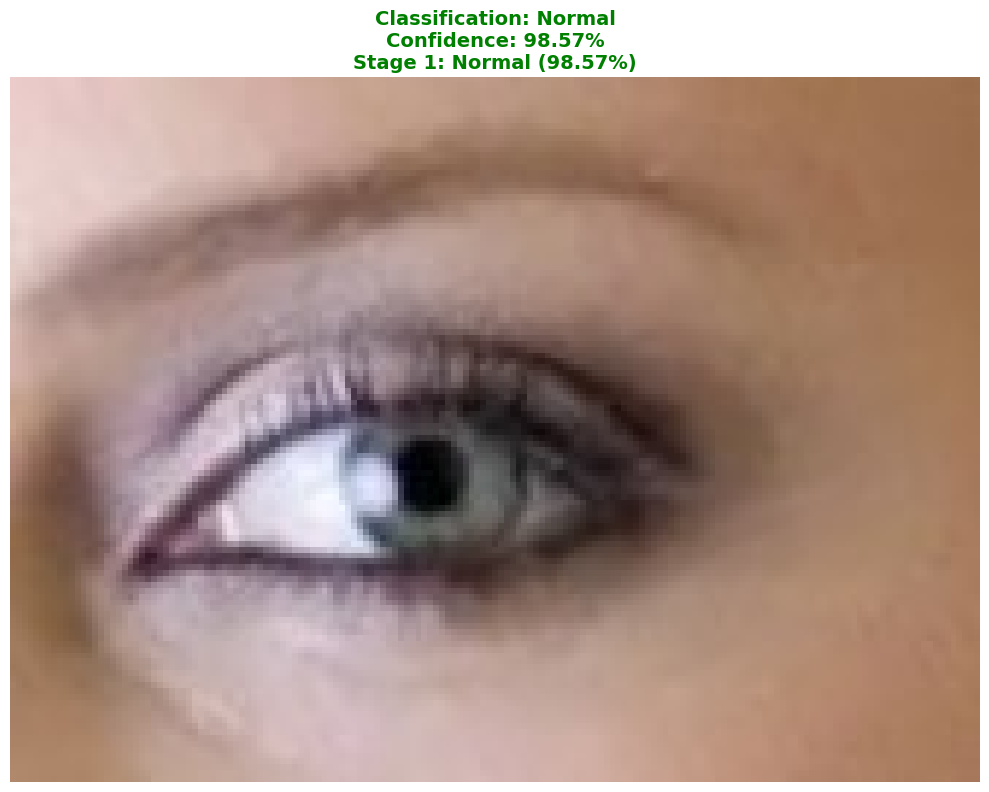

In [36]:
if normal_images:
    print("\nClassifying a normal image:")
    classify_image_no_display(normal_images[0])


Classifying a mature cataract image:


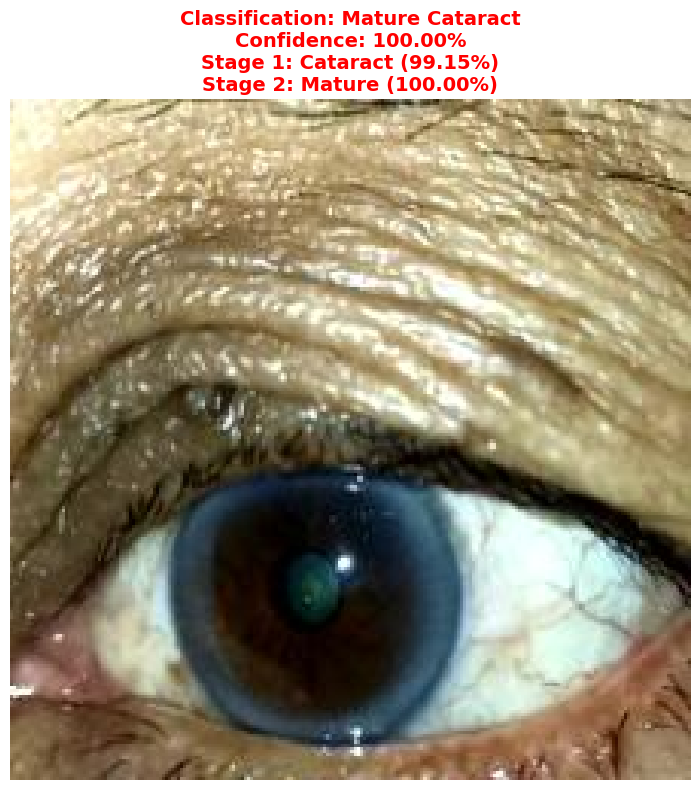

In [37]:
if mature_images:
    print("\nClassifying a mature cataract image:")
    classify_image_no_display(mature_images[0])


Classifying an immature cataract image:


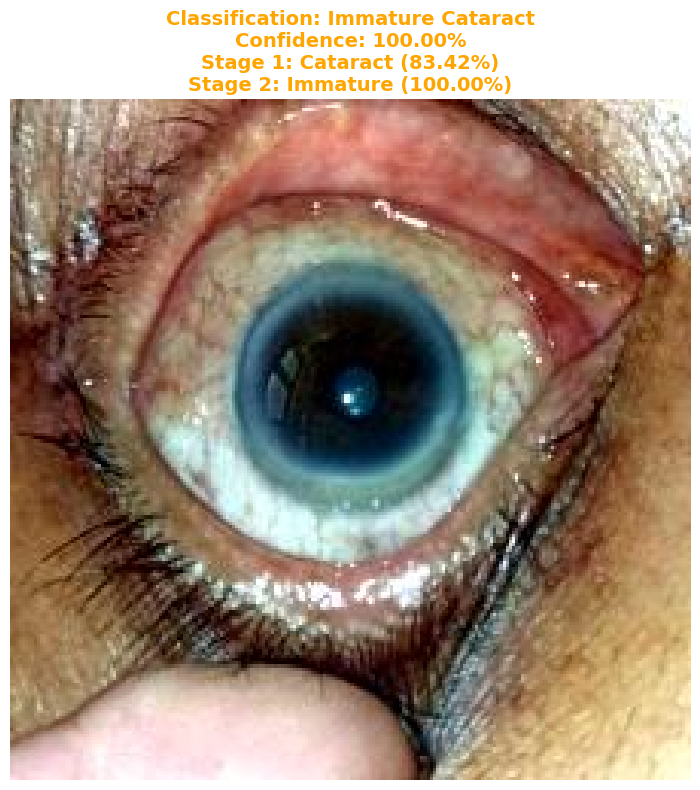

In [38]:
if immature_images:
    print("\nClassifying an immature cataract image:")
    classify_image_no_display(immature_images[0])

---

## Batch Classification

In [39]:
def batch_classify(image_folder, output_csv='classification_results.csv'):
    """
    Classify all images in a folder and save results to CSV
    """
    import pandas as pd
    from tqdm import tqdm
    
    # Find all images
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob.glob(os.path.join(image_folder, '**', ext), recursive=True))
    
    if not image_paths:
        print(f"No images found in {image_folder}")
        return
    
    print(f"Found {len(image_paths)} images to classify")
    
    results = []
    for img_path in tqdm(image_paths, desc="Classifying"):
        frame = cv2.imread(img_path)
        if frame is None:
            continue
        
        final_class, confidence, stage1_result, stage2_result = classify_frame(frame)
        
        results.append({
            'image_path': img_path,
            'final_classification': final_class,
            'confidence': confidence,
            'stage1_class': stage1_result[0],
            'stage1_confidence': stage1_result[1],
            'stage2_class': stage2_result[0] if stage2_result else 'N/A',
            'stage2_confidence': stage2_result[1] if stage2_result else 0
        })
    
    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")
    
    # Summary
    print("\nClassification Summary:")
    print(df['final_classification'].value_counts())
    
    return df

In [40]:
# Example: Batch classify all test images
# Uncomment to run

# results_df = batch_classify('cataract_normal/test', 'cataract_normal_results.csv')

---

## Summary

This notebook provides:

1. **Real-time webcam classification** - `run_realtime_classification()`
2. **Single image classification with OpenCV display** - `classify_single_image()`
3. **Single image classification with matplotlib** - `classify_image_no_display()`
4. **Batch classification** - `batch_classify()`

### Classification Pipeline:
- **Stage 1**: Normal vs Cataract
- **Stage 2**: If Cataract → Mature vs Immature

### Controls (Webcam):
- `q` - Quit
- `s` - Save screenshot
- `p` - Pause/Resume